In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("diabetes.csv")

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148,72,35,0,33.6,0.627,50,1
1,1.0,85,66,29,0,26.6,0.351,31,0
2,8.0,183,64,0,0,23.3,0.672,32,1
3,1.0,89,66,23,94,28.1,0.167,21,0
4,0.0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10.0,101,76,48,180,32.9,0.171,63,0
764,2.0,122,70,27,0,36.8,0.340,27,0
765,5.0,121,72,23,112,26.2,0.245,30,0
766,1.0,126,60,0,0,30.1,0.349,47,1
767,1.0,93,70,31,0,30.4,0.315,23,0


In [5]:
df.shape

(768, 9)

In [6]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               767 non-null    float64
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  767 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    object 
dtypes: float64(3), int64(5), object(1)
memory usage: 54.1+ KB


In [8]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,767.000000,768.000000,768.000000,768.000000,768.000000,768.000000,767.000000,768.000000
mean,3.850065,120.894531,69.105469,20.536458,79.799479,31.992578,0.471995,33.240885
std,3.368910,31.972618,19.355807,15.952218,115.244002,7.884160,0.331529,11.760232
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243500,24.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.371000,29.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626500,41.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


In [9]:
print(df.isnull().sum())

Pregnancies                 1
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    1
Age                         0
Outcome                     0
dtype: int64


In [10]:
missing = (df.isnull().sum()/len(df))*100
print(missing)

Pregnancies                 0.130208
Glucose                     0.000000
BloodPressure               0.000000
SkinThickness               0.000000
Insulin                     0.000000
BMI                         0.000000
DiabetesPedigreeFunction    0.130208
Age                         0.000000
Outcome                     0.000000
dtype: float64


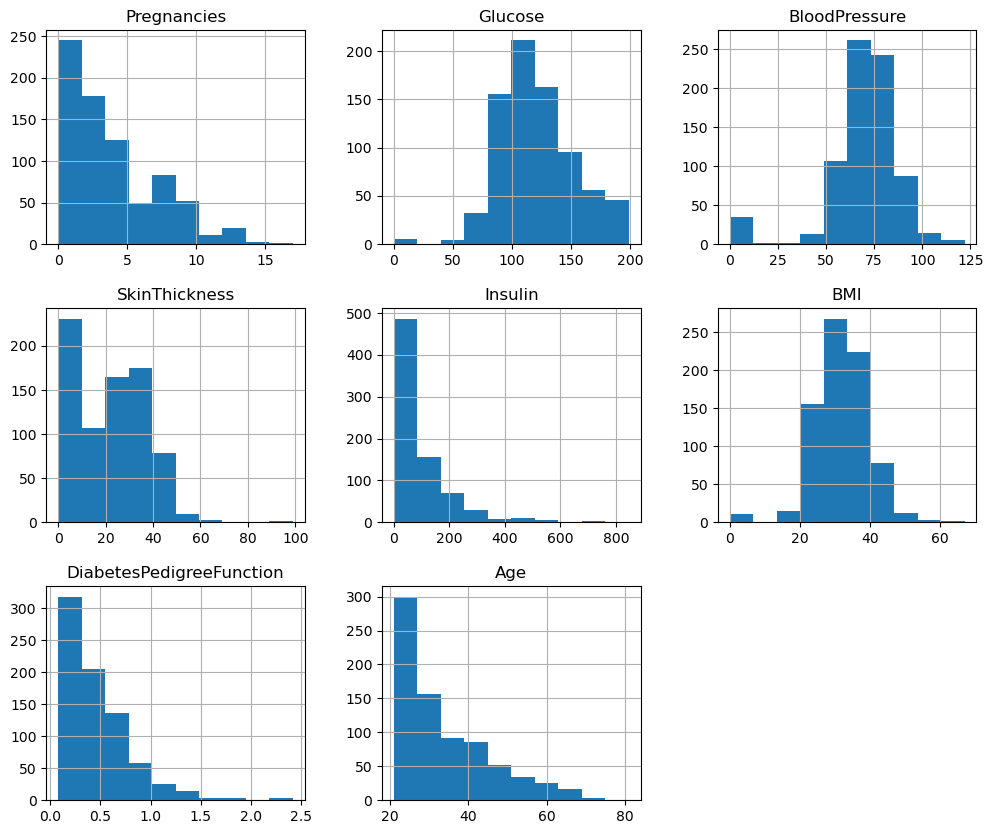

In [11]:
df.hist(figsize=(12,10))
plt.show()

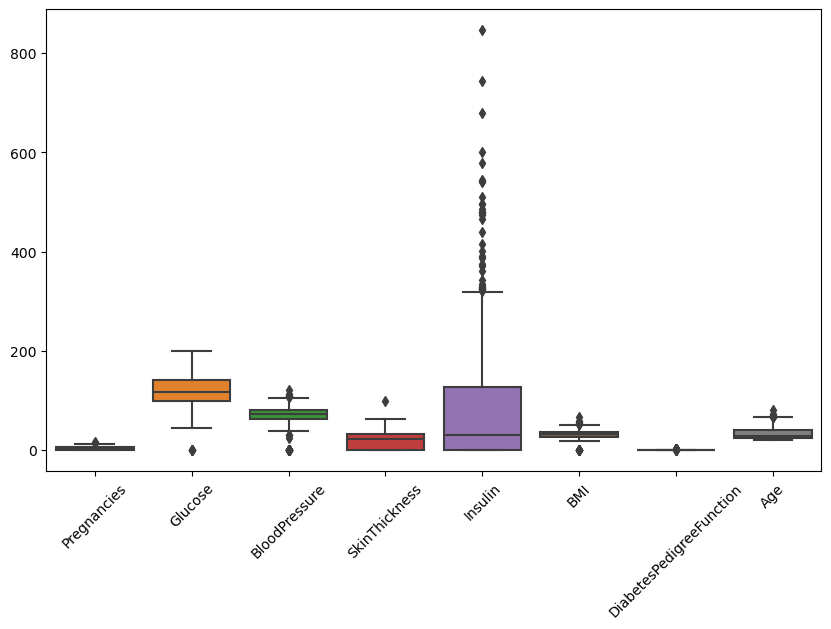

In [14]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

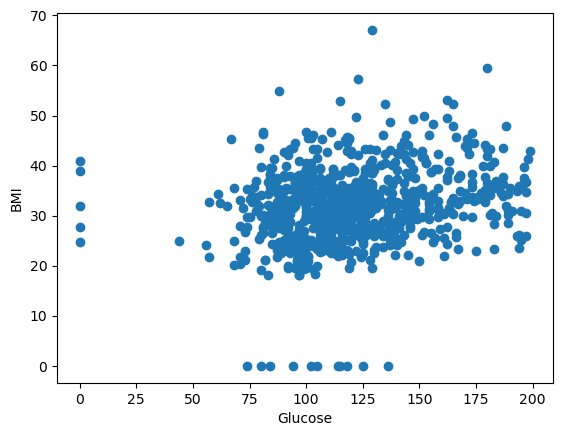

In [15]:
plt.scatter(df["Glucose"], df["BMI"])
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.show()

In [17]:
print(df["Outcome"].value_counts())

Outcome
0    498
1    267
?      3
Name: count, dtype: int64


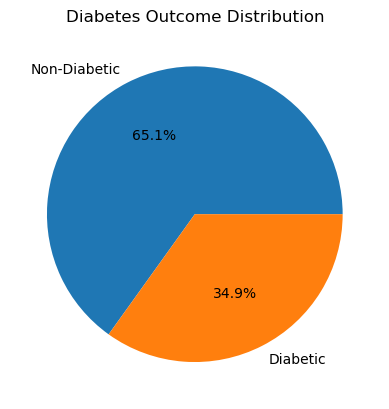

In [ ]:
# Filter out the rows with '?'
cleaned_df = df[df["Outcome"] != "?"]

# Now plot normally
cleaned_df["Outcome"].value_counts().sort_index().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Non-Diabetic", "Diabetic"]
)

plt.ylabel("")
plt.title("Diabetes Outcome Distribution")
plt.show()

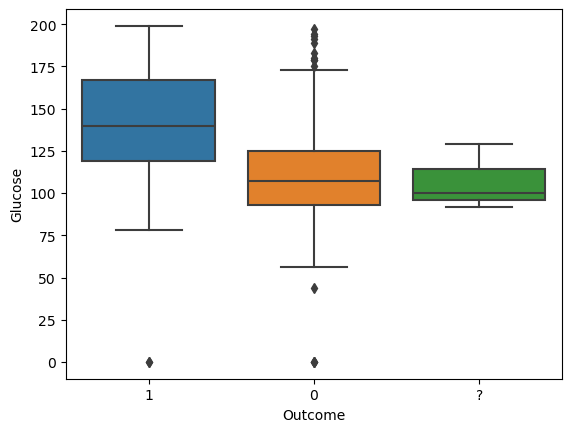

In [23]:
sns.boxplot(x="Outcome", y="Glucose", data=df)
plt.show()

In [26]:
#Add New Column
df["HealthScore"] = df["Glucose"] + df["BMI"]
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0          6.0      148             72             35        0  33.6   
1          1.0       85             66             29        0  26.6   
2          8.0      183             64              0        0  23.3   
3          1.0       89             66             23       94  28.1   
4          0.0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age Outcome  HealthScore  
0                     0.627   50       1        181.6  
1                     0.351   31       0        111.6  
2                     0.672   32       1        206.3  
3                     0.167   21       0        117.1  
4                     2.288   33       1        180.1  


In [30]:
diabetic = df[df["Outcome"] == "1"]
print(diabetic.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0          6.0      148             72             35        0  33.6   
2          8.0      183             64              0        0  23.3   
4          0.0      137             40             35      168  43.1   
6          3.0       78             50             32       88  31.0   
8          2.0      197             70             45      543  30.5   

   DiabetesPedigreeFunction  Age Outcome  HealthScore  
0                     0.627   50       1        181.6  
2                     0.672   32       1        206.3  
4                     2.288   33       1        180.1  
6                     0.248   26       1        109.0  
8                     0.158   53       1        227.5  
